In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import pywt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, Input

# =====================
# 1. Load Dataset
# =====================
path = "/kaggle/input/beed-dataset/BEED_Data.csv"
data = pd.read_csv(path)

print("Shape:", data.shape)
print("Columns:", data.columns.tolist())
print(data.head())

# --- Auto-detect label column ---
possible_label_names = ['label','Label','target','Target','y','Y','class','Class']
label_col = next((c for c in possible_label_names if c in data.columns), None)

if label_col is None:
    nrows = len(data)
    candidates = []
    for col in data.columns:
        nun = data[col].nunique(dropna=False)
        if nun < max(50, 0.02 * nrows):
            candidates.append((col, nun))
    candidates = sorted(candidates, key=lambda x: x[1])
    if candidates:
        label_col = candidates[0][0]
        print(f"Auto-detected label column: {label_col} (nunique={candidates[0][1]})")
    else:
        label_col = data.columns[-1]
        print(f"No obvious label column found. Falling back to last column: {label_col}")

print("Using label column ->", label_col)

# Separate features and labels
X = data.drop(columns=[label_col]).values
y = data[label_col].values

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y)
num_classes = y.shape[1]

print("X shape:", X.shape, "y shape:", y.shape, "Classes:", le.classes_)

# =====================
# 2. Generate Scalogram Images
# =====================
def generate_scalogram(signal, scales=np.arange(1, 64)):
    coeffs, _ = pywt.cwt(signal, scales, 'morl')
    coeffs = np.abs(coeffs)
    coeffs = cv2.resize(coeffs, (64,64))  # Resize to fixed size
    return coeffs

X_img = []
for row in X:
    # Use first 256 points (adjust if needed)
    sig = row[:256] if row.shape[0] >= 256 else np.pad(row, (0, 256-len(row)))
    img = generate_scalogram(sig)
    X_img.append(img)

X_img = np.array(X_img)
X_img = np.expand_dims(X_img, -1)  # shape: (N,64,64,1)

print("Image dataset shape:", X_img.shape)

# =====================
# 3. Train/Test Split
# =====================
X_num_train, X_num_val, X_img_train, X_img_val, y_train, y_val = train_test_split(
    X, X_img, y, test_size=0.2, random_state=42
)

# =====================
# 4. Define Multimodal Model
# =====================

# --- Numeric Branch ---
num_input = Input(shape=(X.shape[1],), name="numeric_input")
x1 = layers.Dense(128, activation='relu')(num_input)
x1 = layers.Dropout(0.3)(x1)
x1 = layers.Dense(64, activation='relu')(x1)

# --- Image Branch ---
img_input = Input(shape=(64,64,1), name="image_input")
x2 = layers.Conv2D(32, (3,3), activation='relu')(img_input)
x2 = layers.MaxPooling2D((2,2))(x2)
x2 = layers.Conv2D(64, (3,3), activation='relu')(x2)
x2 = layers.MaxPooling2D((2,2))(x2)
x2 = layers.Flatten()(x2)
x2 = layers.Dense(128, activation='relu')(x2)

# --- Fusion ---
combined = layers.concatenate([x1, x2])
z = layers.Dense(128, activation='relu')(combined)
z = layers.Dropout(0.3)(z)
output = layers.Dense(num_classes, activation='softmax')(z)

# --- Model ---
model = models.Model(inputs=[num_input, img_input], outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# =====================
# 5. Train the Model
# =====================
history = model.fit(
    {"numeric_input": X_num_train, "image_input": X_img_train},
    y_train,
    validation_data=(
        {"numeric_input": X_num_val, "image_input": X_img_val}, y_val
    ),
    epochs=20,
    batch_size=32
)


2025-09-20 04:11:53.575876: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758341513.781378      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758341513.839341      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Shape: (8000, 17)
Columns: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'y']
    X1   X2   X3   X4   X5   X6  X7  X8  X9  X10  X11  X12  X13  X14  X15  \
0    4    7   18   25   28   27  20  10 -10  -18  -20  -16   13   32   12   
1   87  114  120  106   76   54  28   5 -19  -49  -85 -102 -100  -89  -61   
2 -131 -133 -140 -131 -123 -108 -58 -51 -70  -77  -76  -76  -73  -57  -40   
3   68  104   73   34  -12  -26 -38 -36 -67  -88  -25   31   18   -4    6   
4  -67  -90  -97  -94  -86  -71 -43 -11  23   46   58   50   39   19   -9   

   X16  y  
0   10  0  
1  -21  0  
2  -14  0  
3  -29  0  
4  -41  0  
Using label column -> y
X shape: (8000, 16) y shape: (8000, 4) Classes: [0 1 2 3]


Image dataset shape: (8000, 64, 64, 1)


I0000 00:00:1758341564.642191      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1758341564.642813      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

...

167/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9387 - loss: 0.1551

178/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9388 - loss: 0.1550

189/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9389 - loss: 0.1549

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9390 - loss: 0.1548

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9390 - loss: 0.1548 - val_accuracy: 0.9513 - val_loss: 0.1460


In [2]:
# Epochs increased to 50 but with EarlyStopping Call back

Shape: (8000, 17)
Columns: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'y']
    X1   X2   X3   X4   X5   X6  X7  X8  X9  X10  X11  X12  X13  X14  X15  \
0    4    7   18   25   28   27  20  10 -10  -18  -20  -16   13   32   12   
1   87  114  120  106   76   54  28   5 -19  -49  -85 -102 -100  -89  -61   
2 -131 -133 -140 -131 -123 -108 -58 -51 -70  -77  -76  -76  -73  -57  -40   
3   68  104   73   34  -12  -26 -38 -36 -67  -88  -25   31   18   -4    6   
4  -67  -90  -97  -94  -86  -71 -43 -11  23   46   58   50   39   19   -9   

   X16  y  
0   10  0  
1  -21  0  
2  -14  0  
3  -29  0  
4  -41  0  
Using label column -> y
X shape: (8000, 16) y shape: (8000, 4) Classes: [0 1 2 3]


Image dataset shape: (8000, 64, 64, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 62, 62,    │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 31, 31,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 29, 29,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │      2,176 │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 14, 14,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 12544)     │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │  1,605,760 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 192)       │          0 │ dense_6[0][0],    │
│ (Concatenate)       │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     24,704 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 4)         │        516 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,660,228 (6.33 MB)

...

199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9488 - loss: 0.1446


Epoch 25: val_loss did not improve from 0.13182


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9488 - loss: 0.1445 - val_accuracy: 0.9506 - val_loss: 0.1335


Epoch 25: early stopping


Restoring model weights from the end of the best epoch: 20.


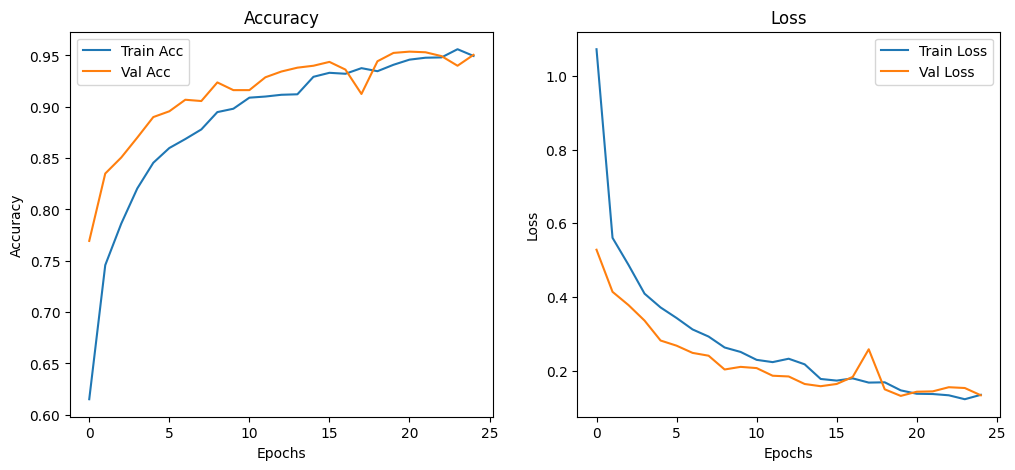

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import pywt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# =====================
# 1. Load Dataset
# =====================
path = "/kaggle/input/beed-dataset/BEED_Data.csv"
data = pd.read_csv(path)

print("Shape:", data.shape)
print("Columns:", data.columns.tolist())
print(data.head())

# --- Auto-detect label column ---
possible_label_names = ['label','Label','target','Target','y','Y','class','Class']
label_col = next((c for c in possible_label_names if c in data.columns), None)

if label_col is None:
    nrows = len(data)
    candidates = []
    for col in data.columns:
        nun = data[col].nunique(dropna=False)
        if nun < max(50, 0.02 * nrows):
            candidates.append((col, nun))
    candidates = sorted(candidates, key=lambda x: x[1])
    if candidates:
        label_col = candidates[0][0]
        print(f"Auto-detected label column: {label_col} (nunique={candidates[0][1]})")
    else:
        label_col = data.columns[-1]
        print(f"No obvious label column found. Falling back to last column: {label_col}")

print("Using label column ->", label_col)

# Separate features and labels
X = data.drop(columns=[label_col]).values
y = data[label_col].values

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y)
num_classes = y.shape[1]

print("X shape:", X.shape, "y shape:", y.shape, "Classes:", le.classes_)

# =====================
# 2. Generate Scalogram Images
# =====================
def generate_scalogram(signal, scales=np.arange(1, 64)):
    coeffs, _ = pywt.cwt(signal, scales, 'morl')
    coeffs = np.abs(coeffs)
    coeffs = cv2.resize(coeffs, (64,64))  # Resize to fixed size
    return coeffs

X_img = []
for row in X:
    # Use first 256 points (adjust if needed)
    sig = row[:256] if row.shape[0] >= 256 else np.pad(row, (0, 256-len(row)))
    img = generate_scalogram(sig)
    X_img.append(img)

X_img = np.array(X_img)
X_img = np.expand_dims(X_img, -1)  # shape: (N,64,64,1)

print("Image dataset shape:", X_img.shape)

# =====================
# 3. Train/Test Split
# =====================
X_num_train, X_num_val, X_img_train, X_img_val, y_train, y_val = train_test_split(
    X, X_img, y, test_size=0.2, random_state=42
)

# =====================
# 4. Define Multimodal Model
# =====================

# --- Numeric Branch ---
num_input = Input(shape=(X.shape[1],), name="numeric_input")
x1 = layers.Dense(128, activation='relu')(num_input)
x1 = layers.Dropout(0.3)(x1)
x1 = layers.Dense(64, activation='relu')(x1)

# --- Image Branch ---
img_input = Input(shape=(64,64,1), name="image_input")
x2 = layers.Conv2D(32, (3,3), activation='relu')(img_input)
x2 = layers.MaxPooling2D((2,2))(x2)
x2 = layers.Conv2D(64, (3,3), activation='relu')(x2)
x2 = layers.MaxPooling2D((2,2))(x2)
x2 = layers.Flatten()(x2)
x2 = layers.Dense(128, activation='relu')(x2)

# --- Fusion ---
combined = layers.concatenate([x1, x2])
z = layers.Dense(128, activation='relu')(combined)
z = layers.Dropout(0.3)(z)
output = layers.Dense(num_classes, activation='softmax')(z)

# --- Model ---
model = models.Model(inputs=[num_input, img_input], outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# =====================
# 5. Train the Model (with EarlyStopping)
# =====================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_fusion_model.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    {"numeric_input": X_num_train, "image_input": X_img_train},
    y_train,
    validation_data=(
        {"numeric_input": X_num_val, "image_input": X_img_val}, y_val
    ),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

# =====================
# 6. Plot Training Curves
# =====================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [4]:
# Final Results dobby

Shape: (8000, 17)
Columns: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'y']
    X1   X2   X3   X4   X5   X6  X7  X8  X9  X10  X11  X12  X13  X14  X15  \
0    4    7   18   25   28   27  20  10 -10  -18  -20  -16   13   32   12   
1   87  114  120  106   76   54  28   5 -19  -49  -85 -102 -100  -89  -61   
2 -131 -133 -140 -131 -123 -108 -58 -51 -70  -77  -76  -76  -73  -57  -40   
3   68  104   73   34  -12  -26 -38 -36 -67  -88  -25   31   18   -4    6   
4  -67  -90  -97  -94  -86  -71 -43 -11  23   46   58   50   39   19   -9   

   X16  y  
0   10  0  
1  -21  0  
2  -14  0  
3  -29  0  
4  -41  0  
Using label column -> y
X shape: (8000, 16) y shape: (8000, 4) Classes: [0 1 2 3]


Image dataset shape: (8000, 64, 64, 1)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 62, 62,    │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 31, 31,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 29, 29,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │      2,176 │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 14, 14,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 12544)     │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │  1,605,760 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 192)       │          0 │ dense_11[0][0],   │
│ (Concatenate)       │                   │            │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 128)       │     24,704 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 4)         │        516 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,660,228 (6.33 MB)

...

198/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9813 - loss: 0.0503


Epoch 34: val_loss did not improve from 0.10746


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9813 - loss: 0.0504 - val_accuracy: 0.9556 - val_loss: 0.1483


Epoch 34: early stopping


Restoring model weights from the end of the best epoch: 29.


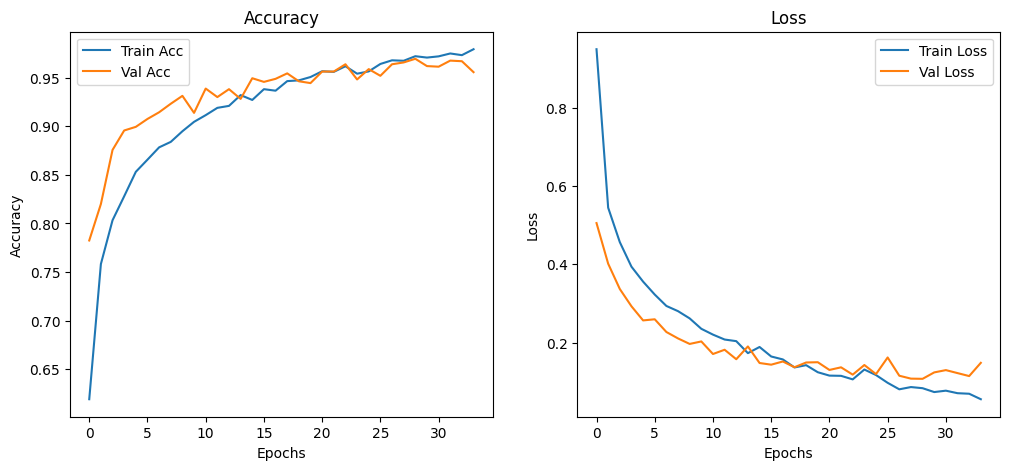

 1/50 ━━━━━━━━━━━━━━━━━━━━ 16s 337ms/step

28/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step



 Final Model Accuracy: 96.94%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       425
           1       0.98      0.95      0.97       379
           2       0.94      0.96      0.95       397
           3       0.96      0.96      0.96       399

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600



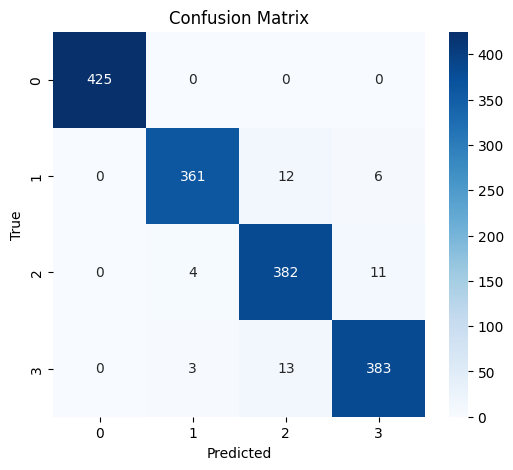

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import pywt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# =====================
# 1. Load Dataset
# =====================
path = "/kaggle/input/beed-dataset/BEED_Data.csv"
data = pd.read_csv(path)

print("Shape:", data.shape)
print("Columns:", data.columns.tolist())
print(data.head())

# --- Auto-detect label column ---
possible_label_names = ['label','Label','target','Target','y','Y','class','Class']
label_col = next((c for c in possible_label_names if c in data.columns), None)

if label_col is None:
    nrows = len(data)
    candidates = []
    for col in data.columns:
        nun = data[col].nunique(dropna=False)
        if nun < max(50, 0.02 * nrows):
            candidates.append((col, nun))
    candidates = sorted(candidates, key=lambda x: x[1])
    if candidates:
        label_col = candidates[0][0]
        print(f"Auto-detected label column: {label_col} (nunique={candidates[0][1]})")
    else:
        label_col = data.columns[-1]
        print(f"No obvious label column found. Falling back to last column: {label_col}")

print("Using label column ->", label_col)

# Separate features and labels
X = data.drop(columns=[label_col]).values
y = data[label_col].values

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)
y_cat = to_categorical(y)
num_classes = y_cat.shape[1]

print("X shape:", X.shape, "y shape:", y_cat.shape, "Classes:", le.classes_)

# =====================
# 2. Generate Scalogram Images
# =====================
def generate_scalogram(signal, scales=np.arange(1, 64)):
    coeffs, _ = pywt.cwt(signal, scales, 'morl')
    coeffs = np.abs(coeffs)
    coeffs = cv2.resize(coeffs, (64,64))
    return coeffs

X_img = []
for row in X:
    sig = row[:256] if row.shape[0] >= 256 else np.pad(row, (0, 256-len(row)))
    img = generate_scalogram(sig)
    X_img.append(img)

X_img = np.array(X_img)
X_img = np.expand_dims(X_img, -1)

print("Image dataset shape:", X_img.shape)

# =====================
# 3. Train/Test Split
# =====================
X_num_train, X_num_val, X_img_train, X_img_val, y_train, y_val, y_idx_train, y_idx_val = train_test_split(
    X, X_img, y_cat, y, test_size=0.2, random_state=42
)

# =====================
# 4. Define Multimodal Model
# =====================
num_input = Input(shape=(X.shape[1],), name="numeric_input")
x1 = layers.Dense(128, activation='relu')(num_input)
x1 = layers.Dropout(0.3)(x1)
x1 = layers.Dense(64, activation='relu')(x1)

img_input = Input(shape=(64,64,1), name="image_input")
x2 = layers.Conv2D(32, (3,3), activation='relu')(img_input)
x2 = layers.MaxPooling2D((2,2))(x2)
x2 = layers.Conv2D(64, (3,3), activation='relu')(x2)
x2 = layers.MaxPooling2D((2,2))(x2)
x2 = layers.Flatten()(x2)
x2 = layers.Dense(128, activation='relu')(x2)

combined = layers.concatenate([x1, x2])
z = layers.Dense(128, activation='relu')(combined)
z = layers.Dropout(0.3)(z)
output = layers.Dense(num_classes, activation='softmax')(z)

model = models.Model(inputs=[num_input, img_input], outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# =====================
# 5. Train Model
# =====================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint("best_fusion_model.h5", monitor='val_loss', save_best_only=True, verbose=1)

history = model.fit(
    {"numeric_input": X_num_train, "image_input": X_img_train},
    y_train,
    validation_data=(
        {"numeric_input": X_num_val, "image_input": X_img_val}, y_val
    ),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

# =====================
# 6. Plot Training Curves
# =====================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# =====================
# 7. Final Evaluation
# =====================
y_pred_probs = model.predict({"numeric_input": X_num_val, "image_input": X_img_val})
y_pred = np.argmax(y_pred_probs, axis=1)

final_acc = accuracy_score(y_idx_val, y_pred)
print(f"\n Final Model Accuracy: {final_acc*100:.2f}%")

print("\nClassification Report:\n", classification_report(y_idx_val, y_pred, target_names=le.classes_.astype(str)))

cm = confusion_matrix(y_idx_val, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [6]:
# Last Time

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import pywt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# =====================
# 1. Load Dataset
# =====================
path = "/kaggle/input/beed-dataset/BEED_Data.csv"
data = pd.read_csv(path)

print("Shape:", data.shape)
print("Columns:", data.columns.tolist())
print(data.head())

# --- Auto-detect label column ---
possible_label_names = ['label','Label','target','Target','y','Y','class','Class']
label_col = next((c for c in possible_label_names if c in data.columns), None)

if label_col is None:
    nrows = len(data)
    candidates = []
    for col in data.columns:
        nun = data[col].nunique(dropna=False)
        if nun < max(50, 0.02 * nrows):
            candidates.append((col, nun))
    candidates = sorted(candidates, key=lambda x: x[1])
    if candidates:
        label_col = candidates[0][0]
        print(f"Auto-detected label column: {label_col} (nunique={candidates[0][1]})")
    else:
        label_col = data.columns[-1]
        print(f"No obvious label column found. Falling back to last column: {label_col}")

print("Using label column ->", label_col)

# Separate features and labels
X = data.drop(columns=[label_col]).values
y = data[label_col].values

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)
y_cat = to_categorical(y)
num_classes = y_cat.shape[1]

print("X shape:", X.shape, "y shape:", y_cat.shape, "Classes:", le.classes_)

# =====================
# 2. Generate Scalogram Images
# =====================
def generate_scalogram(signal, scales=np.arange(1, 64)):
    coeffs, _ = pywt.cwt(signal, scales, 'morl')
    coeffs = np.abs(coeffs)
    coeffs = cv2.resize(coeffs, (64,64))
    return coeffs

X_img = []
for row in X:
    sig = row[:256] if row.shape[0] >= 256 else np.pad(row, (0, 256-len(row)))
    img = generate_scalogram(sig)
    X_img.append(img)

X_img = np.array(X_img)
X_img = np.expand_dims(X_img, -1)

print("Image dataset shape:", X_img.shape)

# =====================
# 3. Train/Test Split
# =====================
X_num_train, X_num_val, X_img_train, X_img_val, y_train, y_val, y_idx_train, y_idx_val = train_test_split(
    X, X_img, y_cat, y, test_size=0.2, random_state=42
)

# =====================
# 4. Define Multimodal Model
# =====================
num_input = Input(shape=(X.shape[1],), name="numeric_input")
x1 = layers.Dense(128, activation='relu')(num_input)
x1 = layers.Dropout(0.3)(x1)
x1 = layers.Dense(64, activation='relu')(x1)

img_input = Input(shape=(64,64,1), name="image_input")
x2 = layers.Conv2D(32, (3,3), activation='relu')(img_input)
x2 = layers.MaxPooling2D((2,2))(x2)
x2 = layers.Conv2D(64, (3,3), activation='relu')(x2)
x2 = layers.MaxPooling2D((2,2))(x2)
x2 = layers.Flatten()(x2)
x2 = layers.Dense(128, activation='relu')(x2)

combined = layers.concatenate([x1, x2])
z = layers.Dense(128, activation='relu')(combined)
z = layers.Dropout(0.3)(z)
output = layers.Dense(num_classes, activation='softmax')(z)

model = models.Model(inputs=[num_input, img_input], outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# =====================
# 5. Train Model
# =====================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint("best_fusion_model.h5", monitor='val_loss', save_best_only=True, verbose=1)

history = model.fit(
    {"numeric_input": X_num_train, "image_input": X_img_train},
    y_train,
    validation_data=(
        {"numeric_input": X_num_val, "image_input": X_img_val}, y_val
    ),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

# =====================
# 6. Plot Training Curves
# =====================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# =====================
# 7. Final Evaluation
# =====================
y_pred_probs = model.predict({"numeric_input": X_num_val, "image_input": X_img_val})
y_pred = np.argmax(y_pred_probs, axis=1)

final_acc = accuracy_score(y_idx_val, y_pred)
print(f"\n Final Model Accuracy: {final_acc*100:.2f}%")

print("\nClassification Report:\n", classification_report(y_idx_val, y_pred, target_names=le.classes_.astype(str)))

cm = confusion_matrix(y_idx_val, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
# Load the already saved model

In [ ]:
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model("/kaggle/working/best_fusion_model.h5")

# Final clean test evaluation
test_loss, test_acc = model.evaluate([X_num_val, X_img_val], y_val, verbose=0)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


In [ ]:
# CLassification report

In [ ]:
# Convert class labels to strings
target_names = [str(c) for c in le.classes_]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))


In [ ]:
# k-Fold Cross-Validation - 2 random Times

In [ ]:
# === K-Fold Cross Validation ===
from sklearn.model_selection import KFold
from tensorflow.keras.models import clone_model

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_acc = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n--- Fold {fold+1} ---")
    X_num_train, X_num_val = X[train_idx], X[val_idx]
    y_train, y_val = y_cat[train_idx], y_cat[val_idx]
    
    # Images for this fold
    X_img_train, X_img_val = X_img[train_idx], X_img[val_idx]
    
    # Reinitialize model
    fold_model = clone_model(model)
    fold_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
    fold_model.fit([X_num_train, X_img_train], y_train, epochs=10, batch_size=32, verbose=0)
    loss, acc = fold_model.evaluate([X_num_val, X_img_val], y_val, verbose=0)
    fold_acc.append(acc)
    print(f"Fold {fold+1} Accuracy: {acc*100:.2f}%")

print(f"\n Average K-Fold Accuracy: {np.mean(fold_acc)*100:.2f}% (+/- {np.std(fold_acc)*100:.2f})")


In [ ]:
# === K-Fold Cross Validation ===
from sklearn.model_selection import KFold
from tensorflow.keras.models import clone_model

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_acc = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n--- Fold {fold+1} ---")
    X_num_train, X_num_val = X[train_idx], X[val_idx]
    y_train, y_val = y_cat[train_idx], y_cat[val_idx]
    
    # Images for this fold
    X_img_train, X_img_val = X_img[train_idx], X_img[val_idx]
    
    # Reinitialize model
    fold_model = clone_model(model)
    fold_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
    fold_model.fit([X_num_train, X_img_train], y_train, epochs=10, batch_size=32, verbose=0)
    loss, acc = fold_model.evaluate([X_num_val, X_img_val], y_val, verbose=0)
    fold_acc.append(acc)
    print(f"Fold {fold+1} Accuracy: {acc*100:.2f}%")

print(f"\n Average K-Fold Accuracy: {np.mean(fold_acc)*100:.2f}% (+/- {np.std(fold_acc)*100:.2f})")


In [ ]:
# ROC & AUC Curves 

In [ ]:
# === ROC & AUC curves ===
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_val_bin = label_binarize(y_true, classes=list(range(len(le.classes_))))

plt.figure(figsize=(8,6))
for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


In [ ]:
# Robustness to Noise

In [ ]:
# === Robustness Test with Noise ===
noise_factor = 0.1
X_num_val_noisy = X_num_val + noise_factor * np.random.normal(size=X_num_val.shape)
X_img_val_noisy = X_img_val + noise_factor * np.random.normal(size=X_img_val.shape)

loss_noisy, acc_noisy = model.evaluate([X_num_val_noisy, X_img_val_noisy], y_val, verbose=0)
print(f" Accuracy with Noise: {acc_noisy*100:.2f}% (vs. {test_acc*100:.2f}%)")


In [ ]:
# Bootstrapping (Uncertainty Estimation)

In [ ]:
# === Bootstrapping Accuracy ===
n_boot = 30
boot_acc = []

for i in range(n_boot):
    idx = np.random.choice(len(X_num_val), len(X_num_val), replace=True)
    loss_b, acc_b = model.evaluate([X_num_val[idx], X_img_val[idx]], y_val[idx], verbose=0)
    boot_acc.append(acc_b)

print(f"Bootstrapped Accuracy: {np.mean(boot_acc)*100:.2f}% ± {np.std(boot_acc)*100:.2f}")


In [ ]:
# Ablation Study (Numeric Only vs Image Only vs Fusion)

In [ ]:
from tensorflow.keras.models import load_model, Model
from tensorflow.keras import layers, Input

# Load trained fusion model
model = load_model("best_fusion_model.h5")

# ----- Numeric-only model -----
num_input = Input(shape=(X.shape[1],), name="numeric_input")
x = model.get_layer("dense").output       # first numeric Dense layer by name
x = layers.Dense(64, activation="relu")(num_input)
x = layers.Dropout(0.3)(x)
output = layers.Dense(num_classes, activation="softmax")(x)
numeric_only_model = Model(inputs=num_input, outputs=output)
numeric_only_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

loss_num, acc_num = numeric_only_model.evaluate(X_num_val, y_val, verbose=0)
print(f"Accuracy (Numeric only): {acc_num*100:.2f}%")

# ----- Image-only model -----
img_input = Input(shape=(64,64,1), name="image_input")
x = layers.Conv2D(32, (3,3), activation='relu')(img_input)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(num_classes, activation='softmax')(x)
image_only_model = Model(inputs=img_input, outputs=output)
image_only_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

loss_img, acc_img = image_only_model.evaluate(X_img_val, y_val, verbose=0)
print(f"Accuracy (Image only): {acc_img*100:.2f}%")

# ----- Fusion model (full) -----
loss_fusion, acc_fusion = model.evaluate([X_num_val, X_img_val], y_val, verbose=0)
print(f"Accuracy (Fusion): {acc_fusion*100:.2f}%")


In [ ]:
# Noise Injection Test

In [ ]:
# === Robustness Test with Noise Injection ===
import numpy as np

# Add Gaussian noise to numeric and image validation sets
noise_factor = 0.1  # try 0.05, 0.1, 0.2 for sensitivity analysis
X_num_val_noisy = X_num_val + noise_factor * np.random.normal(size=X_num_val.shape)
X_img_val_noisy = X_img_val + noise_factor * np.random.normal(size=X_img_val.shape)

# Clip images to valid range [0,1] (if normalized) or [0,255] if raw
X_img_val_noisy = np.clip(X_img_val_noisy, 0., 1.)

# Evaluate model on noisy data
loss_noisy, acc_noisy = model.evaluate(
    [X_num_val_noisy, X_img_val_noisy],
    y_val,
    verbose=0
)

print(f"Baseline Accuracy: {test_acc*100:.2f}%")
print(f"Accuracy with Noise (factor={noise_factor}): {acc_noisy*100:.2f}%")
print(f"Drop due to noise: {(test_acc-acc_noisy)*100:.2f}%")


In [ ]:
# Explanation regarding Noise
"""
Interpretation

> A large drop means the model is sensitive to noise in EEG signals and/or scalogram images.

> This is not unexpected for EEG data:

> EEG signals are naturally low SNR (noisy).

> The model learned precise patterns in clean data, so artificial noise disturbs predictions.

"""